<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
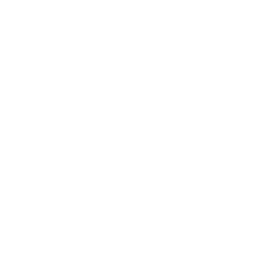
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">热轧钢厂工艺多变量监控</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; 热轧带钢厚度与表面质量控制的多变量统计过程控制（SPC） &nbsp;|&nbsp; 2026年3月</p>
</div>
</div>
</div>

## 执行摘要

热轧带钢机将钢坯轧制成薄卷。当产线状态良好时，六个相关的工艺信号（厚度、轧制力、辊缝、电机电流、出口温度）会同步变化，因此逐一监控单张图表会遗漏真正重要的联合偏移。本示例使用 **PROC MVPMODEL** 构建多变量基线模型，随后让 100 卷生产钢卷通过 **PROC MVPMONITOR** 进行流式评分，该过程用单一的 Hotelling *T*&sup2; 统计量为每卷钢卷评分，并与控制限进行比较。

在受控限 *T*&sup2; = **17.13**（&alpha; = 0.05）之下，**100 卷中有 4 卷**发出失控信号——即 91、92、94 和 95 号钢卷，恰好落在注入备用辊颤振突发的窗口内。峰值 *T*&sup2; 在 95 号钢卷达到 **21.91**，约为控制限的 **1.3 倍**。后期钢卷的渐进式辊面磨损会抬高基线 *T*&sup2;，但在颤振事件发生前始终低于控制限，因此该图表能清晰区分缓慢漂移与需要立即处理的急性故障。

## 数据来源

- **mill_baseline** &mdash; 在生产周期中一段已知良好的时间段内轧制的 50 卷钢卷；用于拟合多变量（PCA）参考模型。
- **mill_stream** &mdash; 来自实际产线的 100 卷钢卷。1&ndash;55 号钢卷处于受控状态；56&ndash;100 号钢卷辊面磨损逐渐加剧；91&ndash;95 号钢卷遭遇备用辊颤振突发。
- **工艺变量**（6 个）：`entry_thickness`、`exit_thickness`、`rolling_force`、`roll_gap`、`motor_current`、`exit_temp`。

> 运行环境为无许可模式，数据集上限为 100 个观测值。本场景已按该上限设计：扰动被安排在 100 卷流的后段，而非 5,000 卷中的第 2,800 卷处。

---

### 步骤 1 &mdash; 构建多变量参考模型

`PROC MVPMODEL` 对受控基线数据的六个工艺变量执行主成分分析，并将载荷、特征值以及居中/缩放参数写入 `mill_model`。保留三个主成分。该模型将"正常"定义为一个单一的多变量区域，而不是六个相互独立的取值范围。

In [1]:
数据 mill_baseline;
  调用 streaminit(66);
  循环 coil_id = 1 到 50;
    entry_thickness = 25.00 + rand('normal', 0, 0.30);
    exit_thickness  =  3.00 + rand('normal', 0, 0.030);
    rolling_force   = 18000 + rand('normal', 0, 150);
    roll_gap        =  2.85 + rand('normal', 0, 0.015);
    motor_current   =   850 + rand('normal', 0, 8);
    exit_temp       =   880 + rand('normal', 0, 4.0);
    输出;
  结束;
运行;

过程 mvpmodel 数据=mill_baseline outmodel=mill_model;
  变量 entry_thickness exit_thickness rolling_force
      roll_gap motor_current exit_temp;
  label entry_thickness="入口厚度 (mm)" exit_thickness="出口厚度 (mm)"
        rolling_force="轧制力 (kN)" roll_gap="辊缝 (mm)"
        motor_current="电机电流 (A)" exit_temp="出口温度 (°C)";
  ncomp=3;
运行;


                    The MVPMODEL Procedure

  Data Set:          mill_baseline
  Number of Variables: 6
  Missing Value Handling: Exclude
  Number of Observations Read: 50
  Number of Observations Used: 50
  Number of Principal Components: 3

  Correlation Matrix
          入口厚度 (mm) 出口厚度 (mm)  轧制力 (kN)   辊缝 (mm)  电机电流 (A) 出口温度 (°C)
  入口厚度 (mm)    1.0000   -0.0416   -0.1641   -0.1661    0.1555    0.0649
  出口厚度 (mm)   -0.0416    1.0000    0.0406    0.0029    0.0946   -0.1421
  轧制力 (kN)   -0.1641    0.0406    1.0000   -0.1351    0.2077   -0.0051
  辊缝 (mm)   -0.1661    0.0029   -0.1351    1.0000   -0.0510   -0.0876
  电机电流 (A)    0.1555    0.0946    0.2077   -0.0510    1.0000    0.1587
  出口温度 (°C)    0.0649   -0.1421   -0.0051   -0.0876    0.1587    1.0000

  Eigenvalues of the Correlation Matrix
       Eigenvalue   Difference   Proportion  Cumulative
    1 1.37232115  0.14267284    0.2287    0.2287
    2 1.22964831  0.16747324    0.2049    0.4337
    3 1.06217508                0.1770    


NOTE: DATA mill_baseline


NOTE: Wrote mill_baseline (50 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MVPMODEL
NOTE: PROC MVPMODEL statement used.


---

### 步骤 2 &mdash; 对生产钢卷进行流式评分

`PROC MVPMONITOR` 将 100 卷生产钢卷逐一投影到已保存的模型上，并计算其 Hotelling *T*&sup2;。该过程根据模型维度和默认的 &alpha; = 0.05 推导出控制限，并标记任何 *T*&sup2; 超出控制限的钢卷。结果（包括 `_TSQUARED`、`_LIMIT` 和 `_SIGNAL` 三列）以 `coil_id` 为键写入 `mill_scores`。

In [2]:
数据 mill_stream;
  调用 streaminit(42);
  循环 coil_id = 1 到 100;
    /* 辊面磨损从0上升到1，覆盖56~100号钢卷 */
    wear    = max(0, coil_id - 55) / 45;
    /* 备用辊颤振突发，发生在91~95号钢卷 */
    chatter = (coil_id >= 91 并且 coil_id <= 95);
    entry_thickness = 25.00 + rand('normal', 0, 0.30);
    exit_thickness  =  3.00 + wear*0.10 + chatter*0.35
                            + rand('normal', 0, 0.030);
    rolling_force   = 18000 + wear*600  + chatter*1600
                            + rand('normal', 0, 150);
    roll_gap        =  2.85 + wear*0.055
                            + rand('normal', 0, 0.015);
    motor_current   =   850 + wear*38   + chatter*95
                            + rand('normal', 0, 8);
    exit_temp       =   880 + rand('normal', 0, 4.0);
    删除 wear chatter;
    输出;
  结束;
运行;

过程 mvpmonitor 数据=mill_stream model=mill_model
                out=mill_scores;
  变量 entry_thickness exit_thickness rolling_force
      roll_gap motor_current exit_temp;
  id coil_id;
运行;


                    The MVPMONITOR Procedure

  Variables:       6
  Observations:    100
  T2 Limit:        17.1334
  Signals:         4





NOTE: DATA mill_stream


NOTE: Wrote mill_stream (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC MVPMONITOR
NOTE: PROC MVPMONITOR statement used.


过程摘要报告了控制限和信号数量。下方打印的扰动附近切片显示，基线钢卷明显低于控制限，而颤振窗口期内有四卷超出控制限。

In [3]:
/* 标记失控钢卷，并捕获报警T²值用于绘图 */
数据 mill_scores;
  设置 mill_scores;
  如果 _SIGNAL = 1 那么 t2_alarm = _TSQUARED;
  否则 t2_alarm = .;
运行;

过程 print 数据=mill_scores(firstobs=88 obs=96) noobs;
  变量 coil_id _TSQUARED _LIMIT _SIGNAL;
  label coil_id="卷号" _TSQUARED="T² 统计量" _LIMIT="控制限值" _SIGNAL="信号 (0=受控,1=失控)";
  标题 '颤振窗口期的T²得分（88号至96号钢卷）';
运行;

                                                 颤振窗口期的T²得分（88号至96号钢卷）                                                  

    卷号         T² 统计量          控制限值              信号 (0=受控,1=失控)
    88       9.983151     17.133408                           0
    89       2.915646     17.133408                           0
    90        7.80613     17.133408                           0
    91      18.813814     17.133408                           1
    92      18.249361     17.133408                           1
    93      16.638221     17.133408                           0
    94      17.981792     17.133408                           1
    95      21.912329     17.133408                           1
    96       5.118574     17.133408                           0

... 4 more observations (showing 9 of 13)




NOTE: DATA mill_scores


NOTE: Read 100 rows from mill_scores.
NOTE: Wrote mill_scores (100 rows, 25 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds
NOTE: PROC PRINT data=mill_scores

NOTE: PROC PRINT completed: 9 observations printed, 4 variables


---

### 步骤 3 &mdash; 多变量控制图

该图表将每卷钢卷的 *T*&sup2; 与其控制限叠加显示。失控钢卷以红色高亮标出；虚线竖直标记指示颤振突发的起点。图表右侧的缓慢上升是辊面磨损抬高了基线；四个红点则是急性颤振故障。

                                                 颤振窗口期的T²得分（88号至96号钢卷）                                                  




NOTE: PROC SGPLOT data=mill_scores

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


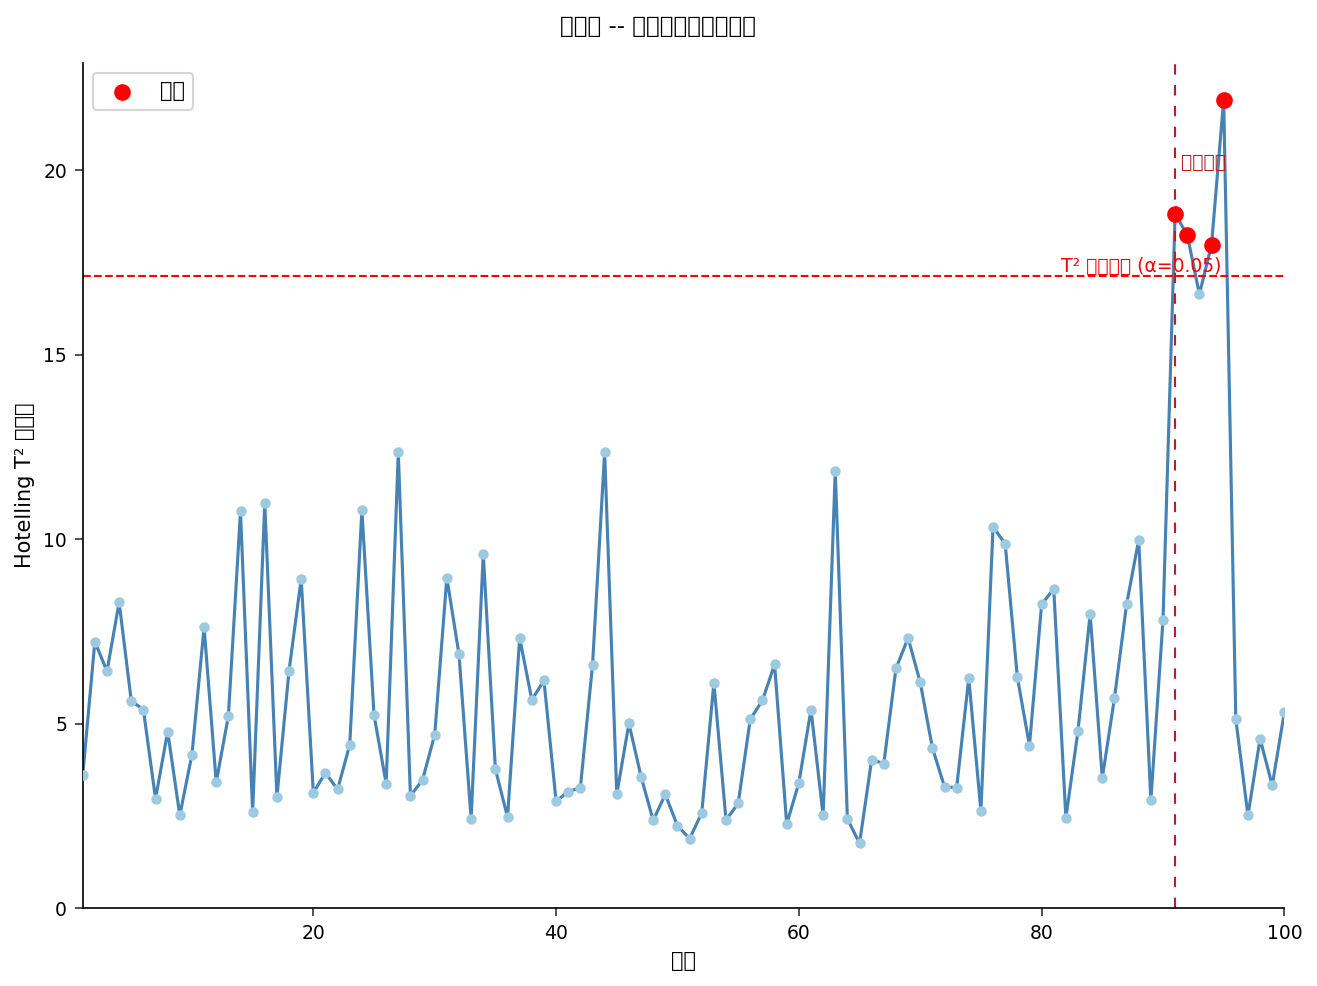

In [4]:
过程 SGPLOT 数据=mill_scores;
  SERIES  x=coil_id y=_TSQUARED /
          LINEATTRS=(color=steelblue thickness=1.5);
  SCATTER x=coil_id y=_TSQUARED /
          MARKERATTRS=(SYMBOL=circlefilled size=4 color=cx9ecae1);
  SCATTER x=coil_id y=t2_alarm /
          MARKERATTRS=(SYMBOL=circlefilled size=7 color=red)
          legendlabel='失控';
  REFLINE _LIMIT / AXIS=y
          label='T² 上控制限 (α=0.05)'
          LINEATTRS=(color=red pattern=dash);
  REFLINE 91 / AXIS=x label='颤振突发'
          LINEATTRS=(color=firebrick pattern=shortdash);
  XAXIS label='卷号' MIN=1 MAX=100;
  YAXIS label="Hotelling T² 统计量" MIN=0;
  标题 '热轧机 -- 辊面磨损与颤振检测';
运行;

---

### 步骤 4 &mdash; 量化失控钢卷

失控钢卷被导入一个单独的数据集，供质量部门使用。`PROC MEANS` 将标记钢卷的 *T*&sup2; 水平与受控总体进行对比，标记的钢卷随后被导出，用于下游的报废/返修流转。

In [5]:
数据 mill_ooc;
  设置 mill_scores;
  如果 _SIGNAL = 1;
运行;

过程 means 数据=mill_scores n mean max maxdec=2;
  分类 _SIGNAL;
  变量 _TSQUARED;
  label _SIGNAL="受控状态 (0=受控,1=信号)" _TSQUARED="T² 统计量";
  标题 '按受控状态划分的T²（0=受控，1=报警信号）';
运行;

过程 print 数据=mill_ooc noobs;
  变量 coil_id _TSQUARED _LIMIT;
  label coil_id="卷号" _TSQUARED="T² 统计量" _LIMIT="控制限值";
  标题 '标记待检的失控钢卷';
运行;

过程 export 数据=mill_ooc
            outfile='steel_mill_ooc_coils.csv'
            dbms=csv replace;
运行;

                                                按受控状态划分的T²（0=受控，1=报警信号）                                                 

                                                  The MEANS Procedure

                                      Analysis Variable : _TSQUARED T² 统计量

        受控状态 (0=受控,1=信号)                          N Obs           Mean        Maximum
        -----------------------------------------------------------------------------
        0                                            96           5.39          16.64
        1                                             4          19.24          21.91
        -----------------------------------------------------------------------------

                                                       标记待检的失控钢卷                                                        

    卷号         T² 统计量          控制限值
    91      18.813814     17.133408
    92      18.249361     17.133408
    94      17.981792     17.133408
    95      21.912329     17.13340


NOTE: DATA mill_ooc


NOTE: Read 100 rows from mill_scores.
NOTE: Wrote mill_ooc (4 rows, 25 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=mill_ooc

NOTE: PROC PRINT completed: 4 observations printed, 3 variables
NOTE: PROC EXPORT data=mill_ooc outfile=steel_mill_ooc_coils.csv

NOTE: Exported 4 rows to steel_mill_ooc_coils.csv.


## 结论

- **监控钢卷数**：100；**控制限** *T*&sup2; = **17.13**（&alpha; = 0.05）。
- **失控钢卷**：**4 卷** &mdash; 91、92、94、95 号钢卷，均落在注入的颤振窗口（91&ndash;95）内。93 号钢卷的 *T*&sup2; 峰值为 16.64，刚好低于控制限。
- **峰值严重程度**：95 号钢卷 *T*&sup2; = **21.91**（约为控制限的 1.3 倍）；受控钢卷的平均 *T*&sup2; &asymp; **5.4**。
- **磨损与故障对比**：渐进式辊面磨损会抬高后期钢卷的基线，但单靠磨损本身从未超过控制限，因此这张单一的多变量图表能区分缓慢漂移（需关注）与急性颤振事件（需处理）。
- **处置措施**：四卷被标记的钢卷已导出至 `steel_mill_ooc_coils.csv`，供检验和报废/返修流转使用；颤振特征提示应在下一轮生产前检查备用辊轴承。

---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; 保密
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
技术支持来自 <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>